# House Price Prediction — Linear Regression

This notebook implements a **Linear Regression** model for predicting house sale prices using the Kaggle House Prices dataset.

**Model:** Linear Regression  
**Dataset:** Kaggle House Prices Dataset  
**Link:** https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/data  
**Metric:** RMSE and R² Score  
**Algorithm:** Linear Regression  
**Output:** `../../results/linear_regression_results.json` 

## 1. Import Libraries

In [17]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

print('Libraries imported successfully.')

Libraries imported successfully.


## 2. Load Dataset

In [18]:
# Load the dataset
df = pd.read_csv('../../data/train.csv')

print(f'Dataset shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Dataset shape: (1460, 81)
Columns: ['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 3. Exploratory Data Analysis (EDA)

In [19]:
# Basic statistics
print('=== Dataset Info ===')
print(df.info())
print()
print('=== Target Variable (SalePrice) Statistics ===')
print(df['SalePrice'].describe())

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   

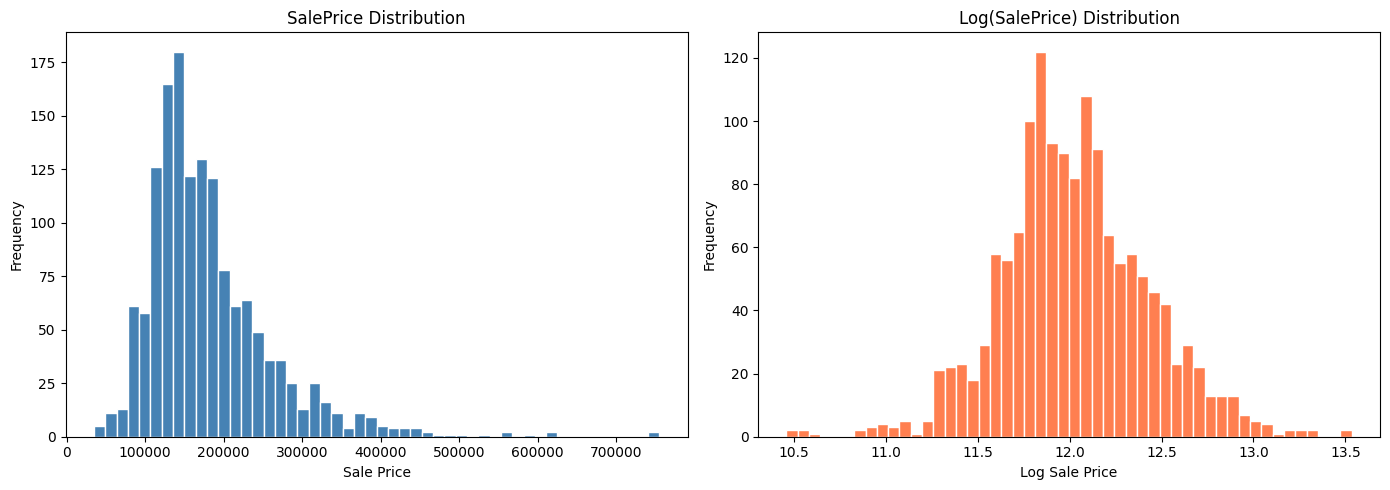

In [20]:
# Visualise SalePrice distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['SalePrice'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('SalePrice Distribution')
axes[0].set_xlabel('Sale Price')
axes[0].set_ylabel('Frequency')

axes[1].hist(np.log1p(df['SalePrice']), bins=50, color='coral', edgecolor='white')
axes[1].set_title('Log(SalePrice) Distribution')
axes[1].set_xlabel('Log Sale Price')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('./linear_regression_saleprice_dist.png', dpi=150)
plt.show()

In [21]:
# Correlation heatmap of top numeric features
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()['SalePrice'].drop('SalePrice').sort_values(ascending=False)

print('Top 10 features correlated with SalePrice:')
print(corr.head(10))
print()
print('Bottom 5 (negative correlation):')
print(corr.tail(5))

Top 10 features correlated with SalePrice:
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
Name: SalePrice, dtype: float64

Bottom 5 (negative correlation):
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePrice, dtype: float64


## 4. Data Preprocessing

In [22]:
# Drop the Id column (not a feature)
df = df.drop(columns=['Id'])

# Separate features and target
X = df.drop(columns=['SalePrice'])
y = df['SalePrice']

print(f'Features shape: {X.shape}')
print(f'Target shape  : {y.shape}')

Features shape: (1460, 79)
Target shape  : (1460,)


In [23]:
# Handle missing values
# Numeric columns  → fill with median
# Categorical cols → fill with mode (most frequent value)

numeric_cols    = X.select_dtypes(include=[np.number]).columns
categorical_cols = X.select_dtypes(exclude=[np.number]).columns

X[numeric_cols]    = X[numeric_cols].fillna(X[numeric_cols].median())
X[categorical_cols] = X[categorical_cols].fillna(X[categorical_cols].mode().iloc[0])

print(f'Missing values after handling: {X.isnull().sum().sum()}')

Missing values after handling: 0


In [24]:
# Encode categorical features using Label Encoding
le = LabelEncoder()
for col in categorical_cols:
    X[col] = le.fit_transform(X[col].astype(str))

print(f'Final feature matrix shape: {X.shape}')
X.head()

Final feature matrix shape: (1460, 79)


,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,60,3,65.0,8450,1,0,3,3,0,4,...,0,0,2,2,2,0,2,2008,8,4
1,20,3,80.0,9600,1,0,3,3,0,2,...,0,0,2,2,2,0,5,2007,8,4
2,60,3,68.0,11250,1,0,0,3,0,4,...,0,0,2,2,2,0,9,2008,8,4
3,70,3,60.0,9550,1,0,0,3,0,0,...,0,0,2,2,2,0,2,2006,8,0
4,60,3,84.0,14260,1,0,0,3,0,2,...,0,0,2,2,2,0,12,2008,8,4


## 5. Train / Test Split

In [25]:
# 80% train — 20% test split  (random_state=42 for reproducibility)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training samples : {X_train.shape[0]}')
print(f'Testing  samples : {X_test.shape[0]}')

Training samples : 1168
Testing  samples : 292


## 6. Model Training

In [26]:
# Train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

print('Linear Regression model trained successfully.')

Linear Regression model trained successfully.


## 7. Evaluation

In [27]:
# Predictions
y_pred = model.predict(X_test)

# Metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print('=' * 40)
print('       Linear Regression Results')
print('=' * 40)
print(f'  RMSE    : {rmse:,.2f}')
print(f'  R² Score: {r2:.4f}')
print('=' * 40)

       Linear Regression Results
  RMSE    : 35,312.14
  R² Score: 0.8374


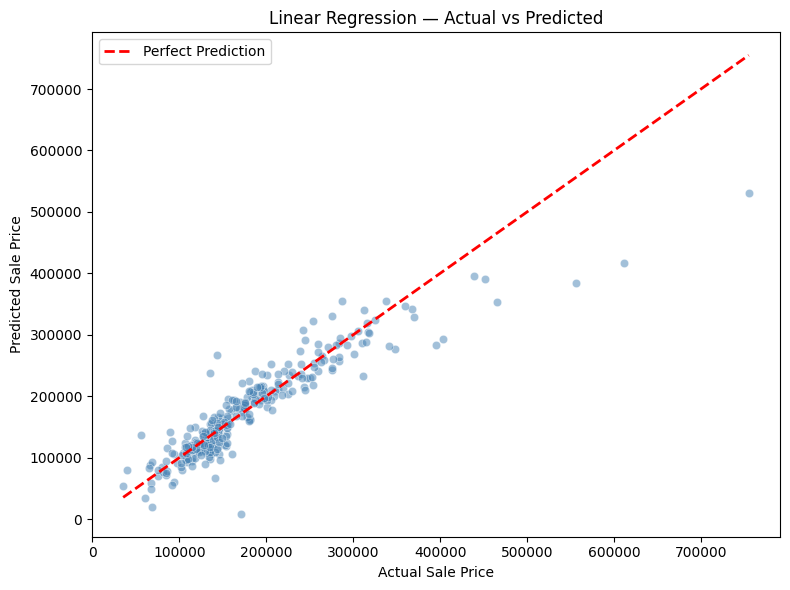

In [28]:
# Actual vs Predicted scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='steelblue', edgecolors='white', linewidth=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Sale Price')
plt.ylabel('Predicted Sale Price')
plt.title('Linear Regression — Actual vs Predicted')
plt.legend()
plt.tight_layout()
plt.savefig('./linear_regression_actual_vs_pred.png', dpi=150)
plt.show()

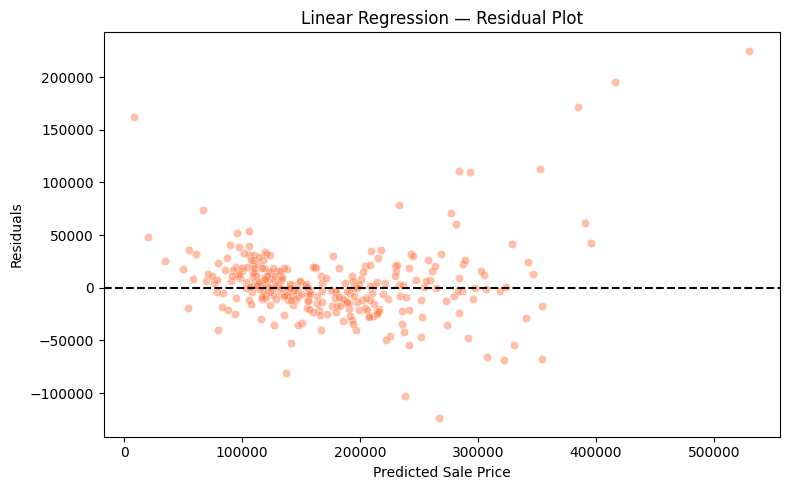

In [29]:
# Residual plot
residuals = y_test - y_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.5, color='coral', edgecolors='white', linewidth=0.5)
plt.axhline(0, color='black', linestyle='--', linewidth=1.5)
plt.xlabel('Predicted Sale Price')
plt.ylabel('Residuals')
plt.title('Linear Regression — Residual Plot')
plt.tight_layout()
plt.savefig('./linear_regression_residuals.png', dpi=150)
plt.show()

## 8. Save Results

In [30]:
# Save results to JSON — same format used by random_forest and svr
results = {
    'model': 'linear_regression',
    'RMSE': round(rmse, 2),
    'R2'  : round(r2,   4)
}

with open('../../results/linear_regression_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print('Results saved to ../../results/linear_regression_results.json')
print(json.dumps(results, indent=2))

Results saved to ../../results/linear_regression_results.json
{
  "model": "linear_regression",
  "RMSE": 35312.14,
  "R2": 0.8374
}
